In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

In [33]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,6)

In [34]:
df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [36]:
df.describe().round(3)

,Quantity,UnitPrice,CustomerID
count,541909.000,541909.000,406829.000
mean,9.552,4.611,15287.691
std,218.081,96.760,1713.600
min,-80995.000,-11062.060,12346.000
25%,1.000,1.250,13953.000
50%,3.000,2.080,15152.000
75%,10.000,4.130,16791.000
max,80995.000,38970.000,18287.000


In [37]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [38]:
df = df.dropna(subset=["CustomerID"])
df["Description"] = df["Description"].fillna("Unknown")

In [39]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [40]:
df = df[df["Quantity"] > 0]

In [41]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [42]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [43]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day

In [44]:
total_revenue = df["Revenue"].sum()

print("Total Revenue: ", total_revenue)

Total Revenue:  8911407.904


In [45]:
avg_order_value = df.groupby("InvoiceNo")["Revenue"].sum().mean()

print("Average Order Value: ", round(avg_order_value, 4))

Average Order Value:  480.7622


In [46]:
df["CustomerID"].nunique()

4339

In [47]:
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

country_sales.head(10)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

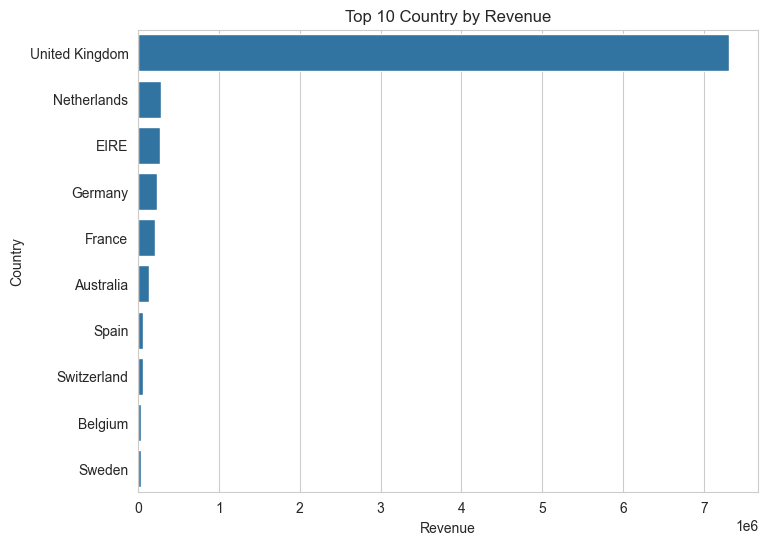

In [48]:
top_countries = country_sales.head(10)

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Country by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

In [49]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)

top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

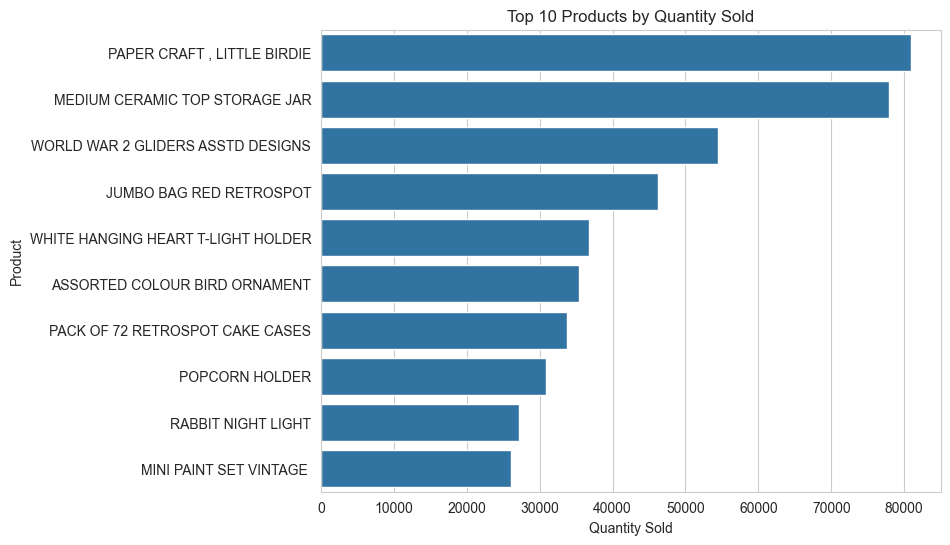

In [50]:
top_products = top_products.head(10)

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()

In [51]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()

monthly_revenue.head(10)

Month
1      569445.040
2      447137.350
3      595500.760
4      469200.361
5      678594.560
6      661213.690
7      600091.011
8      645343.900
9      952838.382
10    1039318.790
Name: Revenue, dtype: float64

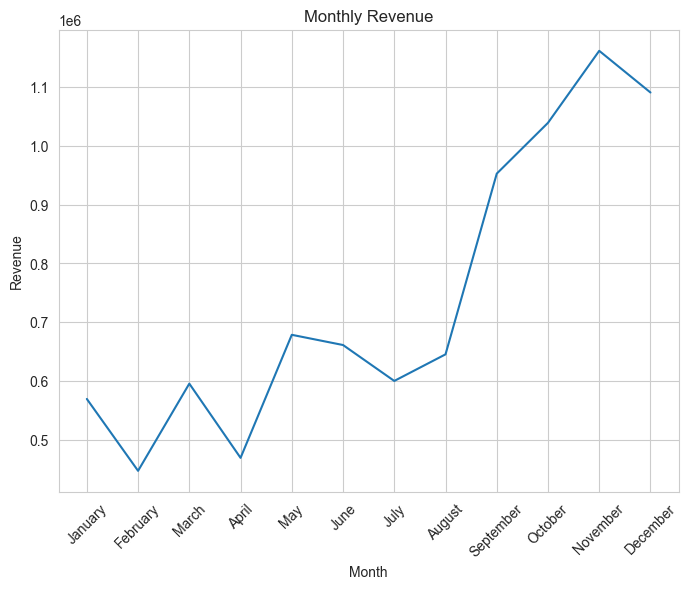

In [52]:
monthly_revenue.index = [calendar.month_name[m] for m in monthly_revenue.index]

sns.lineplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [57]:
product_sales = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False)

cumulative = product_sales.cumsum() / product_sales.sum()

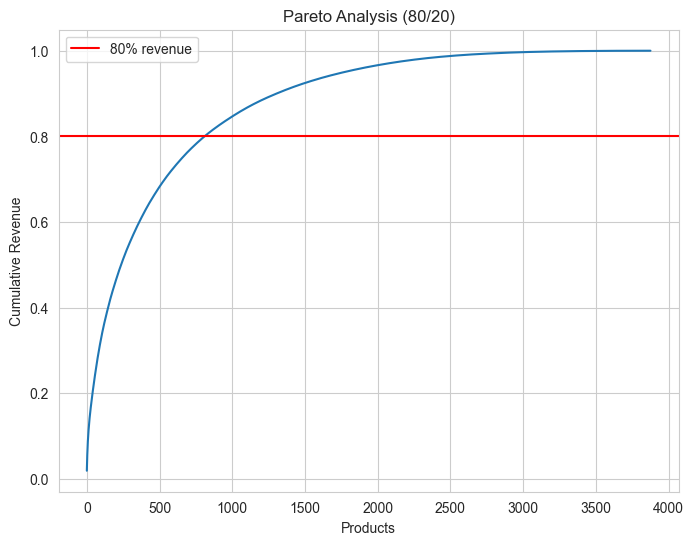

In [58]:
plt.plot(cumulative.values)
plt.axhline(y=0.8, color="red", label="80% revenue")
plt.title("Pareto Analysis (80/20)")
plt.legend()
plt.xlabel("Products")
plt.ylabel("Cumulative Revenue")
plt.show()

In [55]:
top_customers = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64

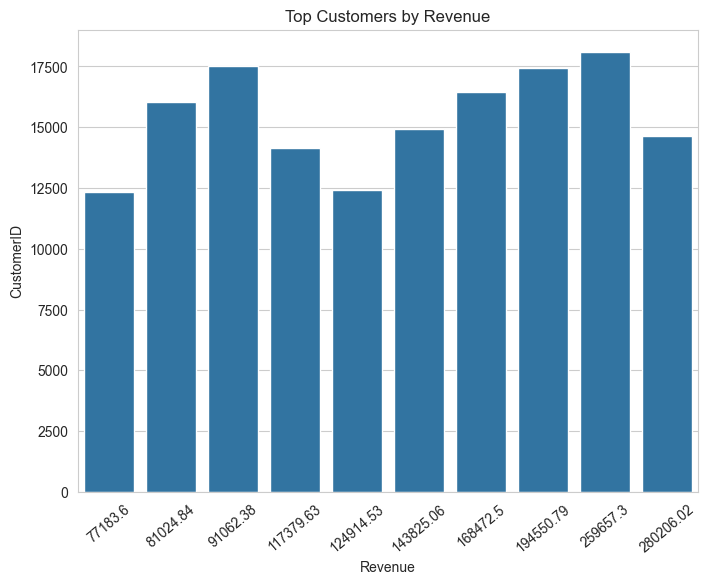

In [56]:
sns.barplot(
    x=top_customers.values,
    y=top_customers.index
)

plt.title("Top Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("CustomerID")
plt.xticks(rotation=40)
plt.show()